In [ ]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from coreforecast.seasonal import find_season_length
from utilsforecast.plotting import plot_series
from utilsforecast.losses import mae, rmse, smape, mase
from functools import partial
from utilsforecast.evaluation import evaluate
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller

In [44]:
df = pd.read_csv('climate_EDA.csv', parse_dates=["date"], index_col = "date")
ts = ['co2_emission', 'energy_consumption']
exog_cols = ['humidity','urban_population', 'energy_price']
base_cols = ['unique_id', 'ds', 'y']

y = df.resample('W').agg({
    'co2_emission': 'mean',
    'energy_consumption': 'mean',
    'urban_population': 'mean',
    'humidity': 'mean',
    'energy_price': 'sum',
})

y = y.iloc[1:-2]

date_index = y.index

panel_list = [
    pd.DataFrame({
        'ds': y.index,
        'y': y[t].values,
        'unique_id': t,
        # Добавляем внешние переменные из y:
        'urban_population': y['urban_population'].values,
        'humidity': y['humidity'].values,
        'energy_price': y['energy_price'].values
    })
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols]

FH = int(0.42 * y.shape[0])
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

In [ ]:
FREQ = y.index.freq
SEASON = 26 #Как в CO2
print(f"Frequency: {FREQ}, Season energy: {SEASON}")

Frequency: <Week: weekday=6>, Season energy: 26


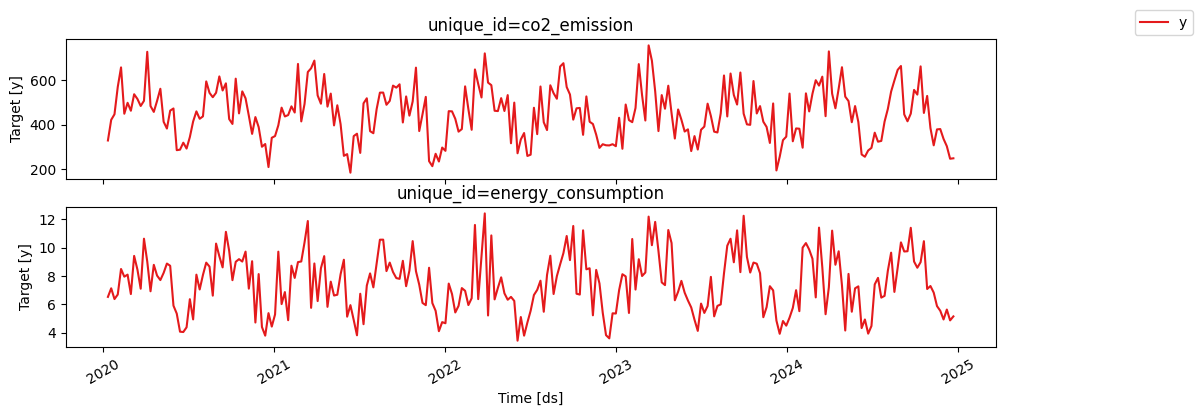

In [46]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax, palette ='Set1')

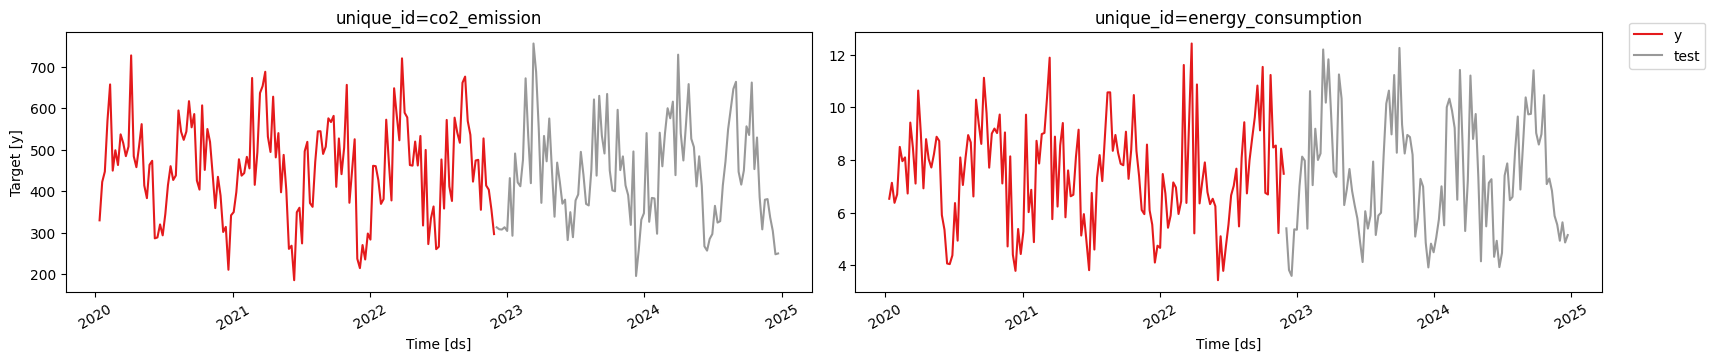

In [47]:
plot_series(df_train, df_test.rename(columns={"y": "test"}),  palette='Set1')

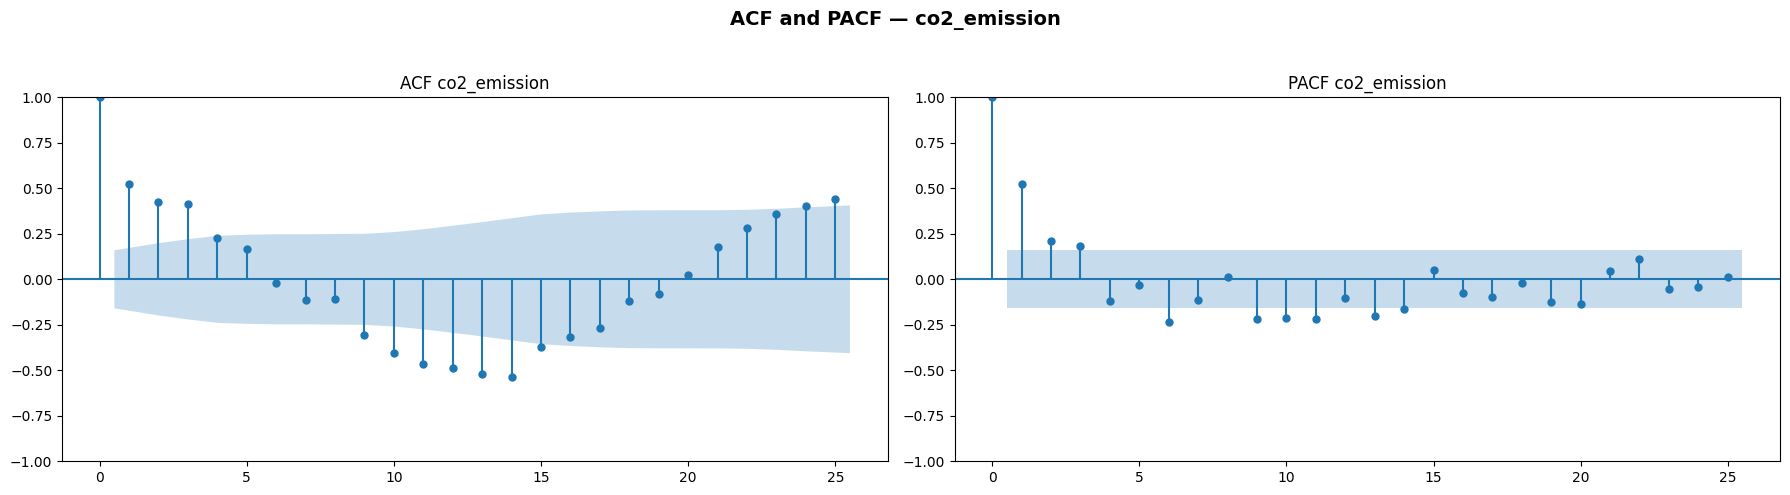

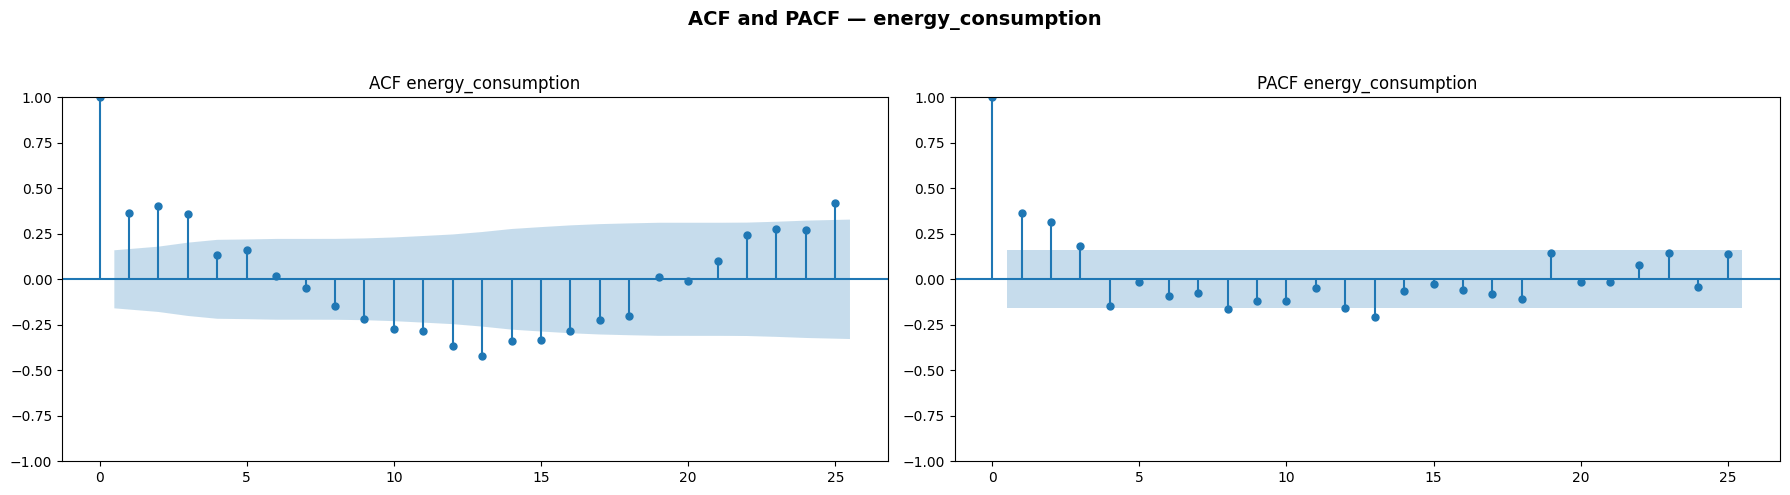

In [48]:
for uid, group in df_train.groupby('unique_id'):
    fig, axes = plt.subplots(1, 2,
                              figsize = (18,5)
                            )
    y = group['y']
    fig.suptitle(f'ACF and PACF — {uid}', fontsize=14, fontweight='bold')
    plot_acf(y, title=f'ACF {uid}', lags=np.arange(SEASON), ax=axes[0]);
    plot_pacf(y, title=f'PACF {uid}', method='ywm', lags=np.arange(SEASON), ax=axes[1]);
    plt.tight_layout(rect=[0, 0, 1, 0.95]);plt.show()

Проверим стационарность с помощью ADF и KPSS

In [49]:
def stationarity_results(y, p_threshold=0.05):
    out = []
    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(y, autolag='AIC')
    out.append({
        'test': 'ADF',
        'stat': adf_stat,
        'p_val': adf_p,
        'stationary': adf_p < p_threshold
    })

    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(y, regression='c', nlags='auto')
    out.append({
        'test': 'KPSS',
        'stat': kpss_stat,
        'p_val': kpss_p,
        'stationary': kpss_p >= p_threshold  # H0: стационарен → не отвергаем, если p >= α
    })

    return pd.DataFrame(out)

all_results = []
for uid, group in df_train.groupby('unique_id'):
    res = stationarity_results(group['y'])
    res['unique_id'] = uid
    all_results.append(res.reset_index())

final_df = pd.concat(all_results, ignore_index=True).drop(columns = 'index')
final_df

/tmp/ipykernel_3114/3643367447.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(y, regression='c', nlags='auto')
/tmp/ipykernel_3114/3643367447.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(y, regression='c', nlags='auto')


,test,stat,p_val,stationary,unique_id
0,ADF,-7.377601,8.639842e-11,True,co2_emission
1,KPSS,0.034543,1.000000e-01,True,co2_emission
2,ADF,-6.096376,1.007766e-07,True,energy_consumption
3,KPSS,0.039849,1.000000e-01,True,energy_consumption


Оба ряда являются стационарными, дифференцирование не требуется

In [50]:
from statsforecast.models import (SeasonalNaive, AutoARIMA, ARIMA, AutoTheta, HoltWinters, AutoETS, AutoCES, MSTL, TBATS)

**Модели прогнозирования**

Были выбраны следующие модели:

*   ARIMA. Параметры выбраны на основе ACF и PACF графиков для energy_consumption
*   AutoARIMA
* SeasonalNaive
* HoltWinters
* AutoETS
* AutoCES
* MSTL
* TBATS



In [51]:
models=[
        ARIMA (order=(4,0,3), season_length=SEASON, seasonal_order=(1, 0, 0)),
        AutoARIMA(season_length=SEASON),
        SeasonalNaive(season_length=SEASON),
        #AutoTheta(season_length=SEASON, decomposition_type="multiplicative"),
        HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add"),
        AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
        AutoCES(season_length=SEASON),
        MSTL(season_length=SEASON,  ),
        TBATS(season_length = SEASON, use_boxcox = True, bc_lower_bound = 0.0, bc_upper_bound = 1, use_trend = True, use_damped_trend = True, use_arma_errors = False,),
  ]

sf_base = StatsForecast(
    models=models,
    freq=FREQ,
)
LEVELS = [75, 90, 95]

fcst_sf = sf_base.forecast(df=df_train, h=FH, level=LEVELS)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics = [mae, rmse, smape]
season_mase = partial(mase, seasonality=SEASON)
metrics +=[season_mase]
metrics_base = evaluate(
    df=eval_sf,
    train_df=df_train,
    metrics=metrics,
).set_index('metric')

metrics_base

,unique_id,ARIMA,AutoARIMA,SeasonalNaive,HW_Add,ETS,CES,MSTL,TBATS
metric,,,,,,,,,
mae,co2_emission,86.365484,70.818111,82.704683,67.102177,67.305387,66.773307,68.136394,65.896098
mae,energy_consumption,1.673804,1.790563,1.395422,1.289918,1.158112,1.169444,1.153076,1.128966
rmse,co2_emission,106.901778,89.873692,103.208072,86.319179,85.099266,85.612305,86.856993,83.397164
rmse,energy_consumption,1.996440,2.126180,1.757687,1.618374,1.466022,1.503568,1.446197,1.392950
smape,co2_emission,0.098500,0.080598,0.095443,0.076709,0.076290,0.075907,0.077298,0.073811
smape,energy_consumption,0.114777,0.122571,0.097412,0.088496,0.078658,0.078868,0.078024,0.076704
mase,co2_emission,1.105382,0.906393,1.058528,0.858833,0.861434,0.854624,0.872070,0.843397
mase,energy_consumption,0.969277,1.036891,0.808070,0.746974,0.670647,0.677209,0.667731,0.653769


In [52]:
from utilsforecast.losses import quantile_loss

metrics_quantile = evaluate(
    df=eval_sf,
    train_df=df_train,
    metrics=[quantile_loss],   # только quantile_loss
    level=LEVELS,
)

metrics_quantile.pivot_table(
    index=['unique_id', 'metric'],
    values=['ARIMA', 'AutoARIMA', 'SeasonalNaive', 'HW_Add', 'ETS', 'CES', 'MSTL', 'TBATS']
)

ARIMA  AutoARIMA        CES  \
unique_id          metric                                                  
co2_emission       quantile_loss_q0.025   5.269469   5.195337   4.873448   
                   quantile_loss_q0.05    9.475032   8.757174   8.335326   
                   quantile_loss_q0.125  20.001482  17.377293  17.156983   
                   quantile_loss_q0.875  24.074749  20.032167  18.479602   
                   quantile_loss_q0.95   11.457276   9.749453   9.856922   
                   quantile_loss_q0.975   5.974862   5.553456   5.684034   
energy_consumption quantile_loss_q0.025   0.096004   0.096937   0.100541   
                   quantile_loss_q0.05    0.166878   0.176247   0.177245   
                   quantile_loss_q0.125   0.362433   0.390833   0.332920   
                   quantile_loss_q0.875   0.441301   0.468365   0.321315   
                   quantile_loss_q0.95    0.206321   0.228164   0.171878   
                   quantile_loss_q0.975   0.107983   0.118181   0.101722   

                                               ETS     HW_Add       MSTL  \
unique_id          metric                                                  
co2_emission       quantile_loss_q0.025   3.836432   4.274676   5.609891   
                   quantile_loss_q0.05    6.978565   7.858531  10.108509   
                   quantile_loss_q0.125  15.830035  16.742083  19.067976   
                   quantile_loss_q0.875  19.194314  19.310965  19.587517   
                   quantile_loss_q0.95   10.408699  10.407802  10.947263   
                   quantile_loss_q0.975   6.635375   6.284988   6.864621   
energy_consumption quantile_loss_q0.025   0.084228   0.102212   0.101579   
                   quantile_loss_q0.05    0.145900   0.177443   0.166211   
                   quantile_loss_q0.125   0.293987   0.355044   0.297824   
                   quantile_loss_q0.875   0.281237   0.322243   0.299827   
                   quantile_loss_q0.95    0.148270   0.164714   0.149627   
                   quantile_loss_q0.975   0.092382   0.095788   0.085505   

                                         SeasonalNaive      TBATS  
unique_id          metric                                          
co2_emission       quantile_loss_q0.025       8.124541   3.845041  
                   quantile_loss_q0.05       13.659369   7.390677  
                   quantile_loss_q0.125      24.210883  16.081618  
                   quantile_loss_q0.875      24.616821  18.387778  
                   quantile_loss_q0.95       13.203695   9.726650  
                   quantile_loss_q0.975       7.611348   5.311679  
energy_consumption quantile_loss_q0.025       0.170138   0.086740  
                   quantile_loss_q0.05        0.286359   0.145686  
                   quantile_loss_q0.125       0.504678   0.281155  
                   quantile_loss_q0.875       0.483000   0.288766  
                   quantile_loss_q0.95        0.276521   0.145535  
                   quantile_loss_q0.975       0.165219   0.078763

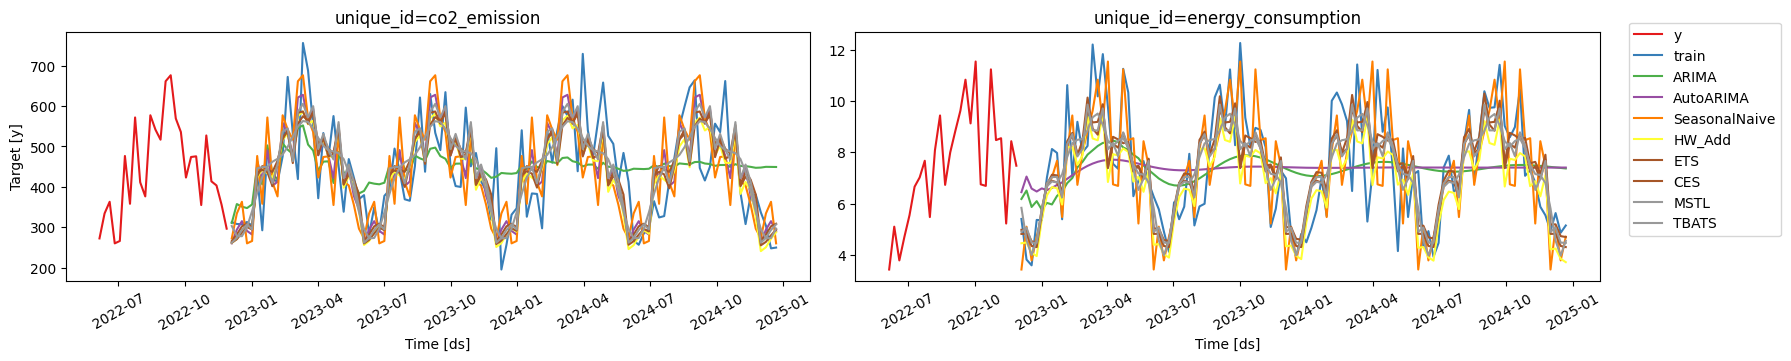

In [53]:
plot_series(df_train,
            forecasts_df=eval_sf.rename(columns = {'y':'train'}),
            max_insample_length=SEASON,
            palette='Set1')

Построим графики с доверительным интервалом 95% для каждой модели по отдельности

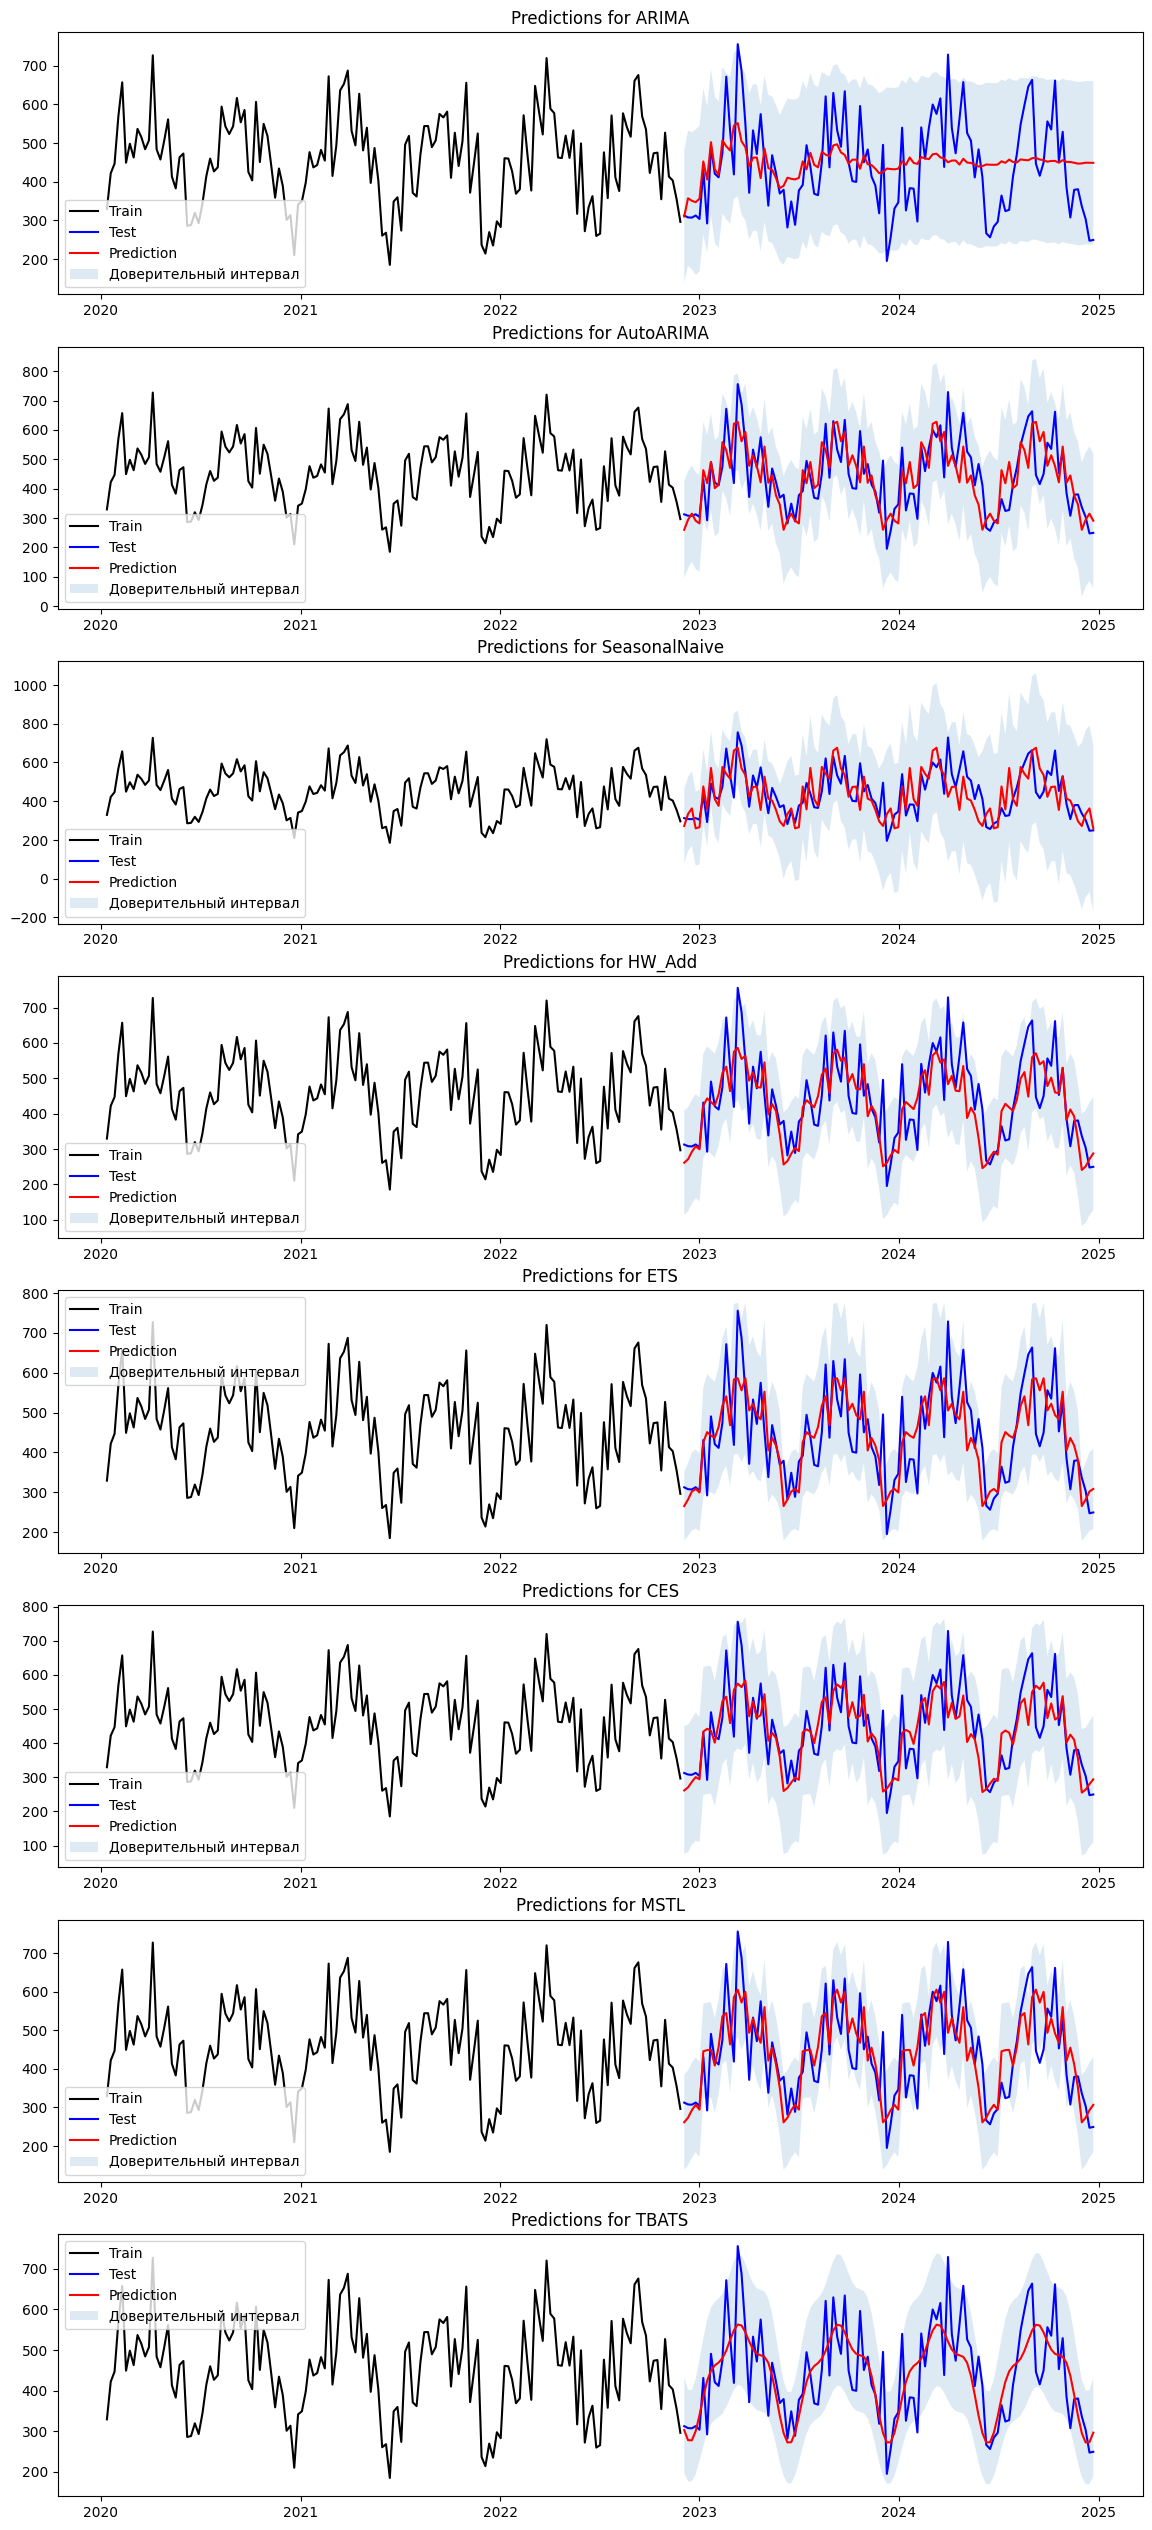

In [54]:
models = ['ARIMA', 'AutoARIMA', 'SeasonalNaive', 'HW_Add', 'ETS', 'CES', 'MSTL', 'TBATS']
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))
#test_len = len(df_test)
test_len = 108
df_train_tail = df_train[df_train['unique_id']=='co2_emission'].tail(test_len*3)
df_predict = eval_sf[eval_sf['unique_id']=='co2_emission'].head(test_len)
df_test_tail = df_test[df_test['unique_id']=='co2_emission'].head(test_len)
for i in range(len(models)):
  curr_model = models[i]
  axes[i].plot(df_train_tail['ds'], df_train_tail['y'], color = 'black', label='Train')
  axes[i].plot(df_test_tail['ds'], df_test_tail['y'], color = 'blue', label='Test')
  axes[i].plot(df_predict['ds'], df_predict[curr_model], color = 'red', label='Prediction')
  lo_col = f'{curr_model}-lo-95'
  hi_col = f'{curr_model}-hi-95'
  if lo_col in df_predict.columns and hi_col in df_predict.columns:
      axes[i].fill_between(df_predict['ds'], df_predict[lo_col], df_predict[hi_col], alpha=0.15, label='Доверительный интервал')
  axes[i].set_title(f"Predictions for {curr_model}")
  axes[i].legend()

plt.show()

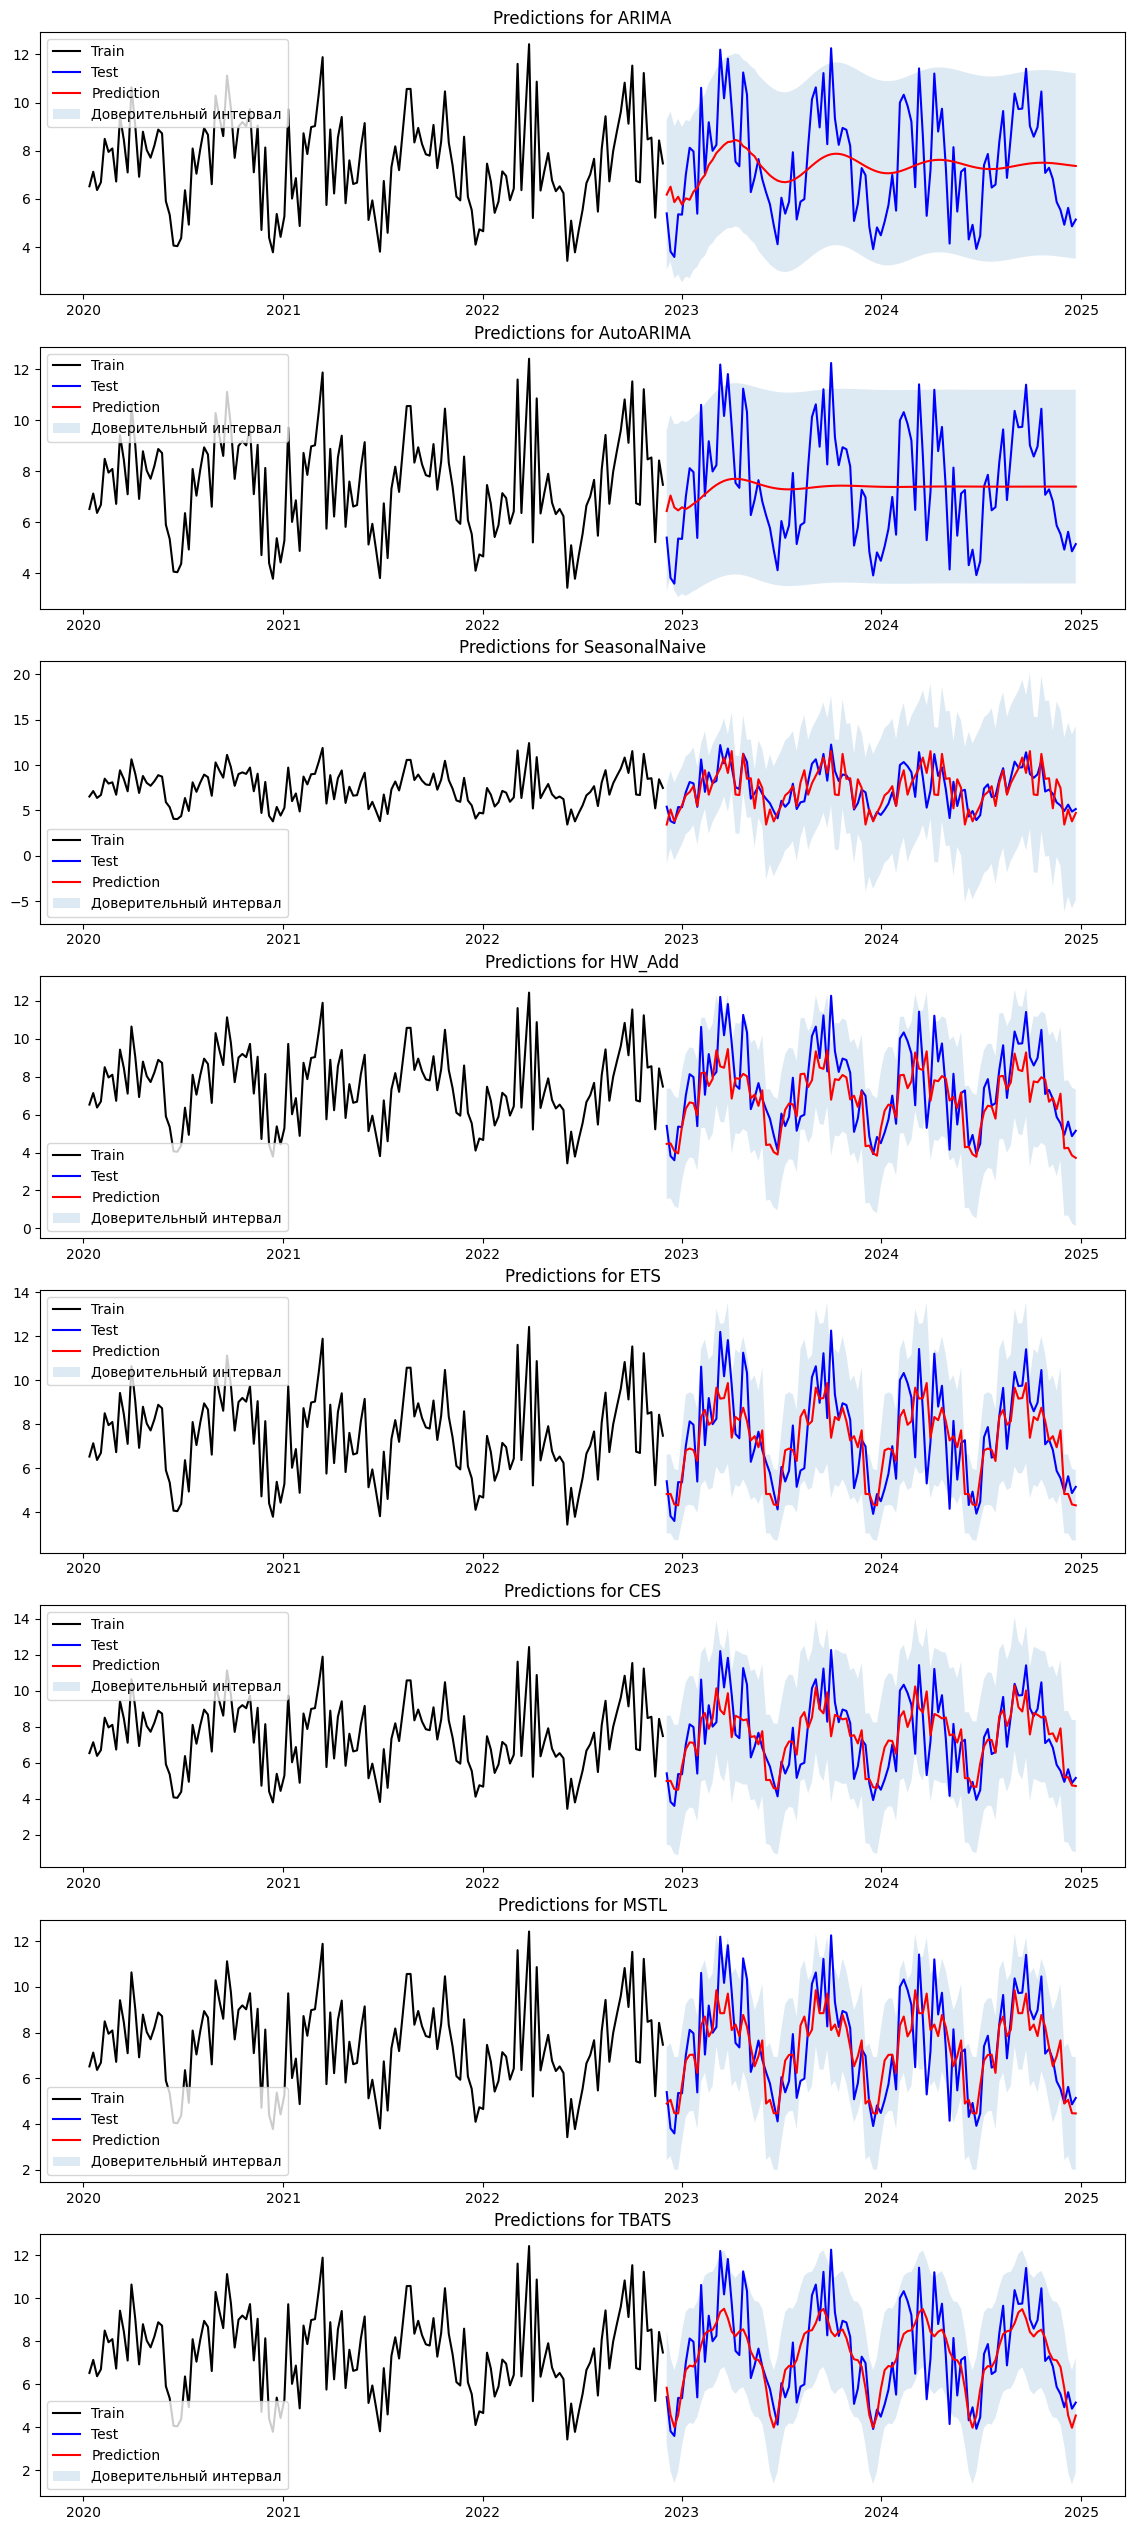

In [55]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))
#test_len = len(df_test)
test_len = 108
df_train_tail = df_train[df_train['unique_id']=='energy_consumption'].tail(test_len*3)
df_predict = eval_sf[eval_sf['unique_id']=='energy_consumption'].head(test_len)
df_test_tail = df_test[df_test['unique_id']=='energy_consumption'].head(test_len)
for i in range(len(models)):
  curr_model = models[i]
  axes[i].plot(df_train_tail['ds'], df_train_tail['y'], color = 'black', label='Train')
  axes[i].plot(df_test_tail['ds'], df_test_tail['y'], color = 'blue', label='Test')
  axes[i].plot(df_predict['ds'], df_predict[curr_model], color = 'red', label='Prediction')
  lo_col = f'{curr_model}-lo-95'
  hi_col = f'{curr_model}-hi-95'
  if lo_col in df_predict.columns and hi_col in df_predict.columns:
      axes[i].fill_between(df_predict['ds'], df_predict[lo_col], df_predict[hi_col], alpha=0.15, label='Доверительный интервал')
  axes[i].set_title(f"Predictions for {curr_model}")
  axes[i].legend()

plt.show()

Так как у энергии и CO2 разные экзогенные факторы, разделим их и посмотри на результаты отдельно

In [56]:
panel_df_en = panel_df[panel_df['unique_id']=='energy_consumption']
panel_df_en.reset_index(drop=True, inplace=True)

df_test_exogs  = panel_df_en[base_cols+exog_cols].groupby("unique_id").tail(FH) #Для энергии используем все экзогенные факторы
df_train_exogs = panel_df_en[base_cols+exog_cols].drop(df_test_exogs.index).reset_index(drop=True)
X_test  = df_test_exogs.drop(columns = 'y')

fcst_exog = sf_base.forecast(df=df_train_exogs, h=FH, X_df=X_test)
eval_exog = df_test.merge(fcst_exog, on=['unique_id', 'ds'])

metrics_exog_en = evaluate(
    df=eval_exog,
    train_df=df_train,
    metrics=metrics,
).set_index('metric')

panel_df_co = panel_df[panel_df['unique_id']=='co2_emission']
panel_df_co.drop(columns=['urban_population', 'energy_price'], inplace=True)
panel_df_co.reset_index(drop=True, inplace=True)

df_test_exogs  = panel_df_co[base_cols+['humidity']].groupby("unique_id").tail(FH) #Для энергии используем все экзогенные факторы
df_train_exogs = panel_df_co[base_cols+['humidity']].drop(df_test_exogs.index).reset_index(drop=True)
X_test  = df_test_exogs.drop(columns = 'y')

fcst_exog = sf_base.forecast(df=df_train_exogs, h=FH, X_df=X_test)
eval_exog = df_test.merge(fcst_exog, on=['unique_id', 'ds'])

metrics_exog_co = evaluate(
    df=eval_exog,
    train_df=df_train,
    metrics=metrics,
).set_index('metric')

metrics_exog = pd.concat([metrics_exog_en, metrics_exog_co])
metrics_exog

/tmp/ipykernel_3114/1588072849.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel_df_co.drop(columns=['urban_population', 'energy_price'], inplace=True)


,unique_id,ARIMA,AutoARIMA,SeasonalNaive,HW_Add,ETS,CES,MSTL,TBATS
metric,,,,,,,,,
mae,energy_consumption,1.496283,1.784260,1.395422,1.289918,1.158112,1.169444,1.153076,1.128966
rmse,energy_consumption,1.836880,2.127025,1.757687,1.618374,1.466022,1.503568,1.446197,1.392950
smape,energy_consumption,0.102743,0.122156,0.097412,0.088496,0.078658,0.078868,0.078024,0.076704
mase,energy_consumption,0.866477,1.033241,0.808070,0.746974,0.670647,0.677209,0.667731,0.653769
mae,co2_emission,86.785988,70.813898,82.704683,67.102177,67.305387,66.773307,68.136394,65.896098
rmse,co2_emission,107.407642,89.908171,103.208072,86.319179,85.099266,85.612305,86.856993,83.397164
smape,co2_emission,0.099017,0.080697,0.095443,0.076709,0.076290,0.075907,0.077298,0.073811
mase,co2_emission,1.110764,0.906339,1.058528,0.858833,0.861434,0.854624,0.872070,0.843397


Посмотрим на остатки

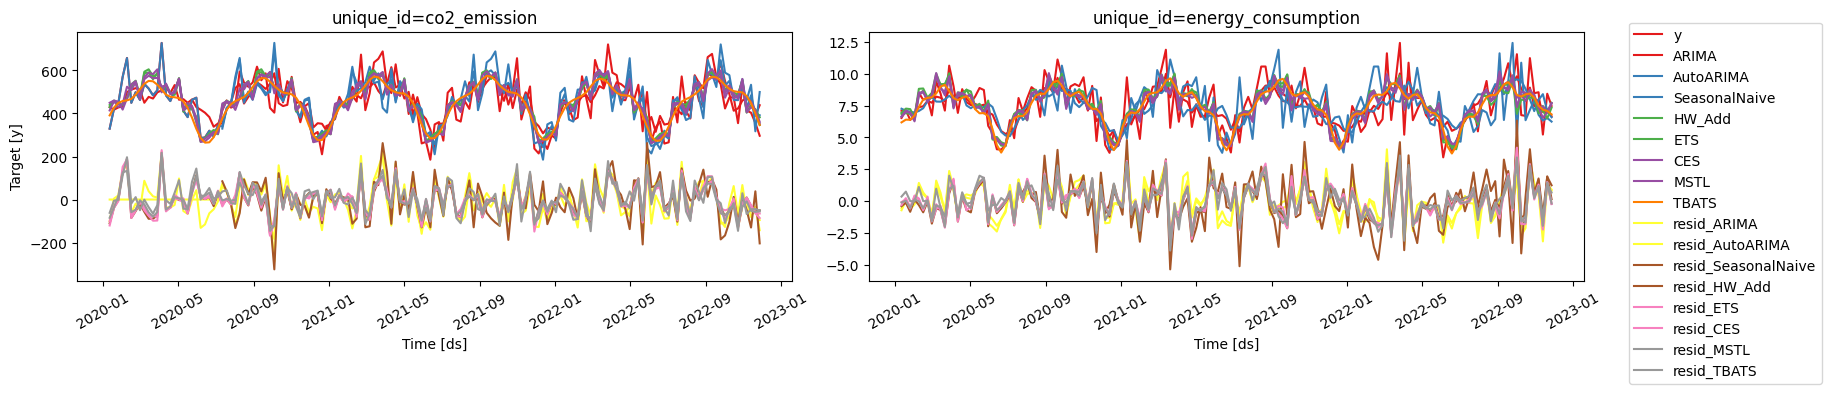

In [57]:
from statsmodels.stats.diagnostic import acorr_ljungbox

sf_base.forecast(h=FH, df=df_train, fitted=True)
fitted_values = sf_base.forecast_fitted_values()

model_names = [getattr(model, 'alias', type(model).__name__) for model in sf_base.models]
for col in model_names:
    fitted_values[f"resid_{col}"] = fitted_values["y"] - fitted_values[col].values

plot_series(df = df_train,forecasts_df = fitted_values.drop(columns = 'y'), palette='Set1')

Остатки не белый шум, автокорелляция есть



Еще раз сравним метрики, в данный раз с более явным выделением лучших

In [58]:
avg_by_series = metrics_base.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

In [59]:
avg_by_series = metrics_exog.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

# Результаты
Можно сделать следующие выводы:
*   TBATS показывает лучшие результаты для обоих рядов
* CES и HW_Add показывают близкие результаты к TBATS для co2_emission и в некоторых случаях могут быть точнее
*   ETS и MSTL показывают близкие результаты к TBATS для energy_consumption
* Экзогенные факторы улучшают предсказание для моделей, которые их используют. Однако, модели без экзогенных факторов все равно показывают предсказания лучше




